<a href="https://colab.research.google.com/github/AAAAA5464/-Trader-Performance-vs-Market-Sentiment-/blob/main/Trader_Performance_vs_Market_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [141]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

plt.style.use('seaborn-v0_8')

In [142]:
# Load datasets
trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

print("\nTrades Missing Values:\n", trades.isnull().sum())
print("\nSentiment Missing Values:\n", sentiment.isnull().sum())

print("\nTrades Duplicates:", trades.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Duplicates: 0
Sentiment Duplicates: 0


In [143]:
# =====================================
# 3️⃣ CLEAN & ALIGN DATES
# =====================================

# Convert trades timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

# Convert Closed PnL to numeric
trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')

# Use existing sentiment date column
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [144]:
# =====================================
# 4️⃣ DAILY PNL PER TRADER
# =====================================

daily_pnl = (
    trades
    .groupby(['date','Account'], as_index=False)['Closed PnL']
    .sum()
    .rename(columns={
        'Account':'trader_id',
        'Closed PnL':'daily_pnl'
    })
)

print(daily_pnl.head())

         date                                   trader_id    daily_pnl
0  2023-01-05  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
1  2023-05-12  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000
2  2024-01-01  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -129.531460
3  2024-01-02  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000
4  2024-01-03  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  8244.241409


In [145]:
# =====================================
# 5️⃣ MERGE WITH SENTIMENT
# =====================================

daily_pnl = daily_pnl.merge(
    sentiment[['date','value','classification']],
    on='date',
    how='left'
)

print(daily_pnl.head())
print(daily_pnl['classification'].value_counts())

         date                                   trader_id    daily_pnl  value  \
0  2023-01-05  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   29.0   
1  2023-05-12  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000   49.0   
2  2024-01-01  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -129.531460   65.0   
3  2024-01-02  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000   71.0   
4  2024-01-03  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  8244.241409   70.0   

  classification  
0           Fear  
1        Neutral  
2          Greed  
3          Greed  
4          Greed  
classification
Greed            191
Fear             157
Extreme Greed    112
Neutral           37
Extreme Fear      33
Name: count, dtype: int64


In [146]:
# Win indicator
trades['win'] = (trades['Closed PnL'] > 0).astype(int)

In [147]:
# Win rate per trader
win_rate = trades.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)

In [148]:
# Average trade size (Exposure proxy)
avg_trade_size = trades.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

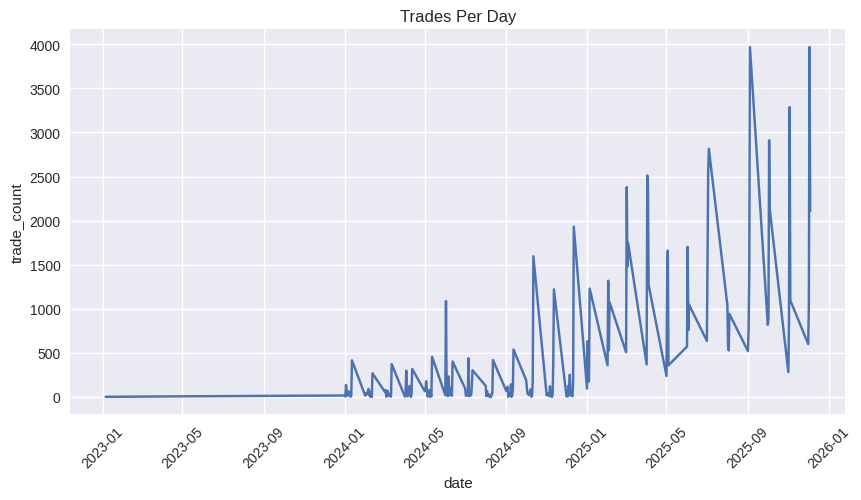

In [149]:
# Trades per day
trades_per_day = trades.groupby('date').size().reset_index(name='trade_count')

plt.figure(figsize=(10,5))
sns.lineplot(data=trades_per_day, x='date', y='trade_count')
plt.xticks(rotation=45)
plt.title("Trades Per Day")
plt.show()

In [150]:
# Long / Short Ratio
long_short = trades.groupby(['date','Side']).size().unstack().fillna(0)
long_short['long_short_ratio'] = \
    long_short.get('BUY',0) / (long_short.get('SELL',0) + 1)

print(long_short.head())

Side         BUY   SELL  long_short_ratio
date                                     
2023-01-05   3.0    0.0          3.000000
2023-05-12   7.0    2.0          2.333333
2024-01-01  10.0    8.0          1.111111
2024-01-02   6.0    0.0          6.000000
2024-01-03  37.0  100.0          0.366337


In [162]:
# Drawdown proxy
trades = trades.sort_values(['Account','date'])

trades['cum_pnl'] = trades.groupby('Account')['Closed PnL'].cumsum()
trades['rolling_max'] = trades.groupby('Account')['cum_pnl'].cummax()
trades['drawdown'] = trades['cum_pnl'] - trades['rolling_max']

ANALYSIS

In [152]:
# Merge sentiment to trades level
trades = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

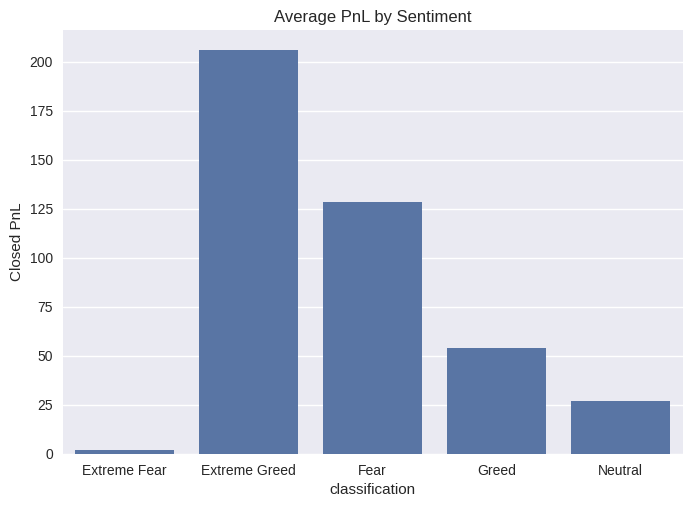

In [153]:
pnl_sentiment = trades.groupby('classification')['Closed PnL'].mean().reset_index()

sns.barplot(data=pnl_sentiment, x='classification', y='Closed PnL')
plt.title("Average PnL by Sentiment")
plt.show()

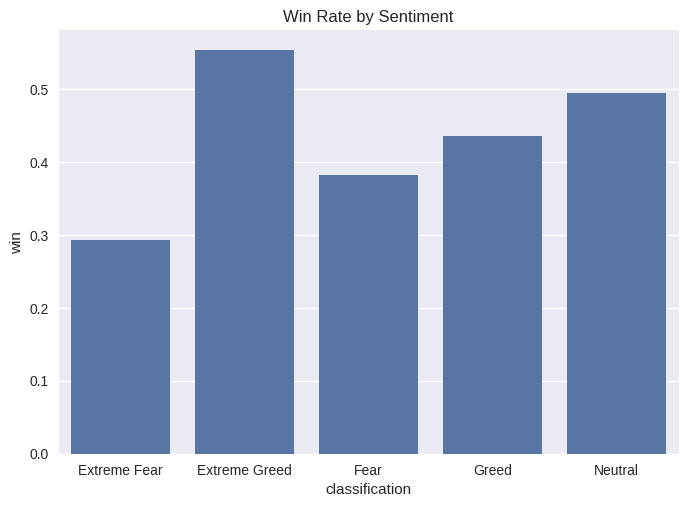

In [154]:
win_sentiment = trades.groupby('classification')['win'].mean().reset_index()

sns.barplot(data=win_sentiment, x='classification', y='win')
plt.title("Win Rate by Sentiment")
plt.show()

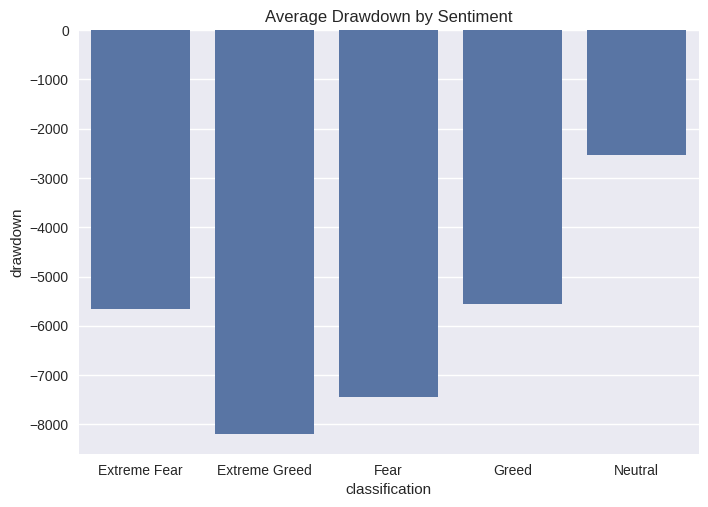

In [155]:
drawdown_sentiment = trades.groupby('classification')['drawdown'].mean().reset_index()

sns.barplot(data=drawdown_sentiment, x='classification', y='drawdown')
plt.title("Average Drawdown by Sentiment")
plt.show()

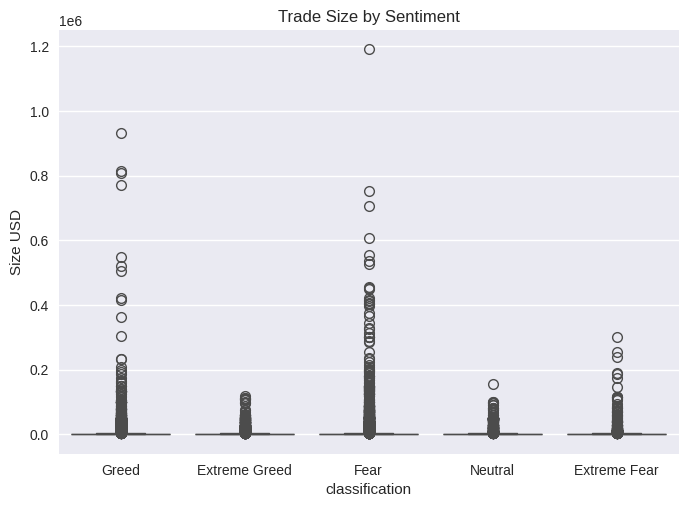

In [156]:
sns.boxplot(data=trades, x='classification', y='Size USD')
plt.title("Trade Size by Sentiment")
plt.show()

In [157]:
exposure = trades.groupby('Account')['Size USD'].mean().reset_index()
threshold = exposure['Size USD'].median()

exposure['segment'] = np.where(
    exposure['Size USD'] > threshold,
    "High Exposure",
    "Low Exposure"
)

print(exposure.head())

                                      Account      Size USD        segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734  High Exposure
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327   Low Exposure
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898  High Exposure
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933   Low Exposure
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782   Low Exposure


In [158]:
freq = trades.groupby('Account').size().reset_index(name='trade_count')
threshold = freq['trade_count'].median()

freq['segment'] = np.where(
    freq['trade_count'] > threshold,
    "Frequent",
    "Infrequent"
)

print(freq.head())

                                      Account  trade_count     segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818    Frequent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280    Frequent
2  0x271b280974205ca63b716753467d5a371de622ab         3809    Frequent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311    Frequent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Infrequent


In [159]:
mean_pnl = trades.groupby('Account')['Closed PnL'].mean()
std_pnl = trades.groupby('Account')['Closed PnL'].std()

consistency = pd.DataFrame({
    'mean_pnl': mean_pnl,
    'std_pnl': std_pnl
}).reset_index()

consistency['segment'] = np.where(
    (consistency['mean_pnl'] > 0) &
    (consistency['std_pnl'] < consistency['std_pnl'].median()),
    "Consistent Winner",
    "Inconsistent"
)

print(consistency.head())

                                      Account    mean_pnl      std_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  4692.452329   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   134.073473   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   542.182659   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530   113.269353   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   255.829091   

             segment  
0       Inconsistent  
1  Consistent Winner  
2       Inconsistent  
3  Consistent Winner  
4  Consistent Winner  


In [160]:
# Target
trades['profit_bucket'] = (trades['Closed PnL'] > 0).astype(int)

# SAFE FEATURES (no pnl-derived fields)
features = trades[['Size USD']]
features = features.join(
    pd.get_dummies(trades['classification'], drop_first=True)
)

X = features
y = trades['profit_bucket']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.66      0.68      0.67     24769
           1       0.52      0.50      0.51     17476

    accuracy                           0.60     42245
   macro avg       0.59      0.59      0.59     42245
weighted avg       0.60      0.60      0.60     42245



In [161]:
cluster_data = trades.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean'
}).dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['cluster'] = kmeans.fit_predict(scaled)

print(cluster_data.head())

                                            Closed PnL      Size USD  cluster
Account                                                                      
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734        2
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327        1
0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898        1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933        1
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782        1
